# TinyGPT

**Autor: Abraham R.**

Este cuaderno es un ejemplo de un modelo GPT realmente pequeño llamado **TinyGPT**.
Repasarás la arquitectura GPT (transformer *decoder*) e implementarás las siguientes tareas:

## Arquitectura de TinyGPT

Diseñado para el [curso NLP‑II](https://github.com/FIUBA-Posgra...), consiste en un **GPT con *Mixture of Experts***, equivalente a modelos como:
- DeepSeek
- Mistral

## Tareas

Usando TinyGPT debes implementar las siguientes modificaciones:
...

## Arquitectura
- Convertir TinyGPT en un *Mixture of Experts* (MoE) con al menos 2 expertos.

## ¿Qué esperar?

- Comprender en profundidad la implementación de un modelo GPT.
- Implementar una capa MoE para crear un modelo GPT de vanguardia.
- Explorar algoritmos de decodificación para generación de texto.

### NOTA

La tokenización está fuera de alcance; usaremos un tokenizador por caracteres, sencillo pero ineficiente.


In [2]:
import torch
from torch import nn
import torch.nn.functional as F
from dataclasses import dataclass, field
from typing import Optional, List, Type
import httpx

from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from trainer import Trainer
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR

## Descargando el conjunto de datos

In [3]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = httpx.get(url)
text = response.text

text = text[:100_000]  # Using 100k characters for speedup
print(text)

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



# Codificación basada en caracteres

In [4]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
def encode(s): return [stoi[c] for c in s]
def decode(l): return ''.join([itos[i] for i in l])
data = torch.tensor(encode(text), dtype=torch.long)

# División entrenamiento/prueba
split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]

# Cargadores de datos

In [5]:
class CharDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int):
        self.data = data
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.block_size]
        y = self.data[idx + 1 : idx + self.block_size + 1]
        return x, y

# Configuración de GPT

In [6]:
@dataclass
class MoEArgs():
    """
    MoE input arguments class.
    """
    num_experts : int = field(default=4)
    num_experts_per_token : int = field(default=2)

@dataclass
class GPTConfig:
    """
    Base class for GPT models.
    """
    block_size: int = 32
    batch_size: int = 8
    n_embd: int = 64
    n_head: int = 4
    n_layer: int = 2
    dropout: float = 0.1
    vocab_size: int = vocab_size
    bias: bool = True
    ff_class: Optional[Type[nn.Module]] = None
    moe : Optional[MoEArgs] = None

config = GPTConfig()
print(config.__dict__)

{'block_size': 32, 'batch_size': 8, 'n_embd': 64, 'n_head': 4, 'n_layer': 2, 'dropout': 0.1, 'vocab_size': 61, 'bias': True, 'ff_class': None, 'moe': None}


In [7]:
train_dataset = CharDataset(train_data, config.block_size)
val_dataset = CharDataset(val_data, config.block_size)

train_loader = DataLoader(train_dataset,
                        batch_size=config.batch_size,
                        shuffle=True,
                        drop_last=True,
                        pin_memory=True,
                        num_workers= 8, # if using mps set num_workers as 0.
                        )
val_loader = DataLoader(val_dataset,
                        batch_size=config.batch_size,
                        shuffle=False,
                        drop_last=True,
                        pin_memory=True,
                        num_workers= 8,
                        )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [8]:
class AttentionHead(nn.Module):
    """
    Scaled Dot-Product Attention Head for Multi-Head Attention.
    """
    def __init__(self, args: GPTConfig) -> None:
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd must be divisible by n_head"
        self.head_dim = args.n_embd // args.n_head

# Proyección QKV combinada
        self.key_query_value = nn.Linear(args.n_embd, 3 * self.head_dim, bias=args.bias)

        self.dropout = nn.Dropout(args.dropout)
        self.block_size = args.block_size
        self.register_buffer('tril', torch.tril(torch.ones(args.block_size, args.block_size)))

    def forward(self, x: torch.Tensor, kv_cache: Optional[torch.Tensor] = None, return_weights=False):
        B, T, C = x.shape
        key_query_value = self.key_query_value(x)  # (B, T, 3 * head_dim)
        k, q, v = torch.chunk(key_query_value, 3, dim=-1)  # (B, T, head_dim) each

        if kv_cache is not None:
            key_cache, value_cache = kv_cache.unbind(dim=0)  # (B, T', head_dim)
            k = torch.cat((key_cache, k), dim=1)
            v = torch.cat((value_cache, v), dim=1)

# Atención de producto punto escalado
        wei = q @ k.transpose(-2, -1) * (self.head_dim ** -0.5)  # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        out = wei @ v  # (B, T, head_dim)

        if return_weights:
            return out, wei

        if kv_cache is not None:
            return out, torch.stack((k, v))

        return out, None

In [9]:
class MultiHeadAttention(nn.Module):
    def __init__(self, args: GPTConfig):
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd must be divisible by n_head"
        self.n_heads = args.n_head
        self.head_dim = args.n_embd // args.n_head

        self.heads = nn.ModuleList([
            AttentionHead(args) for _ in range(self.n_heads)
        ])

        self.proj = nn.Linear(args.n_embd, args.n_embd, bias=args.bias)
        self.dropout = nn.Dropout(args.dropout)

    def forward(self, x, kv_cache=None, return_weights=False):
        all_outputs = []
        all_weights = []
        new_kv_cache = [] if kv_cache is not None else None

        for i, head in enumerate(self.heads):
            head_cache = kv_cache[i] if kv_cache is not None else None
            out, weights_or_kv = head(x, kv_cache=head_cache, return_weights=return_weights)
            all_outputs.append(out)
            if return_weights:
                all_weights.append(weights_or_kv)
            if kv_cache is not None:
                new_kv_cache.append(weights_or_kv)  # weights_or_kv is new kv_cache here

        concat = torch.cat(all_outputs, dim=-1)  # concat along embedding dim
        out = self.dropout(self.proj(concat))

        if return_weights:
            return out, torch.stack(all_weights)
        if kv_cache is not None:
            return out, new_kv_cache
        return out

In [10]:
class FeedForward(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.attn = MultiHeadAttention(config)

        ff_class = config.ff_class if config.ff_class is not None else FeedForward
        self.ff = ff_class(config)

    def forward(self, x, kv_cache=None, return_weights=False):
        attn_out = self.attn(self.ln1(x), kv_cache=kv_cache, return_weights=return_weights)
        if return_weights:
            attn_out, weights = attn_out
        else:
            weights = None

        if isinstance(attn_out, tuple):
            attn_out, updated_kv = attn_out
        else:
            updated_kv = None

        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return (x, updated_kv, weights) if return_weights else (x, updated_kv)

## Arquitectura de TinyGPT

In [11]:
class TinyGPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.config = config

    def forward(self, idx, kv_cache=None, return_weights=False):
        B, T = idx.shape
        tok_emb = self.token_emb(idx)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.pos_emb(pos)[None, :, :]
        x = tok_emb + pos_emb

        new_kv_cache = [] if kv_cache is not None else None
        all_weights = [] if return_weights else None

        for i, block in enumerate(self.blocks):
            layer_kv = kv_cache[i] if kv_cache is not None else None
            if return_weights:
                x, updated_kv, weights = block(x, kv_cache=layer_kv, return_weights=True)
                all_weights.append(weights)  # weights shape: (n_heads, B, T, T)
            else:
                x, updated_kv = block(x, kv_cache=layer_kv)
            if kv_cache is not None:
                new_kv_cache.append(updated_kv)

        x = self.ln_f(x)
        logits = self.head(x)

        if return_weights:
            if kv_cache is not None:
                return logits, new_kv_cache, all_weights
            else:
                return logits, all_weights
        else:
            if kv_cache is not None:
                return logits, new_kv_cache
            return logits

## Función de generación (inferencia)

In [12]:
@torch.no_grad()
def generate(prompt: str, max_new_tokens: int = 100, use_cache: bool = True):
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)
    kv_cache = None

    for _ in range(max_new_tokens):
        if use_cache and kv_cache is not None:
            idx_cond = idx[:, -1:]
        else:
            idx_cond = idx[:, -config.block_size:]

        out = model(idx_cond, kv_cache=kv_cache) if use_cache else model(idx_cond)

        if isinstance(out, tuple):
            logits, kv_cache = out
        else:
            logits = out
            kv_cache = None

        probs = F.softmax(logits[:, -1, :], dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return decode(idx[0].tolist())

# Configuración

In [13]:
device =  'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
m = TinyGPT(config).to(device)
model = torch.compile(m)

In [14]:
optimizer = AdamW(model.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 2

# Entrenamiento

In [15]:
# Instancia del Trainer
trainer = Trainer(
    model=model,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints",
    save_every_n=500
)
# Entrenamiento
for epoch in range(epochs):
    avg_train_loss = trainer.train_model_v2(use_amp=True, dtype=torch.bfloat16)
    print(f"Época {epoch+1} - pérdida de entrenamiento: {avg_train_loss:.4f}")

    val_loss = trainer.eval_model()
    print(f"Época {epoch+1} - pérdida de validación: {val_loss:.4f}")

print("Entrenamiento completo.")

  0%|          | 0/11246 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
W0414 22:13:11.737000 4300 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/d

Época 1 - pérdida de entrenamiento: 2.0789


  0%|          | 0/1246 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
val_loss 2.03776: 100%|██████████| 1246/1246 [00:10<00:00, 121.02it/s]


Época 1 - pérdida de validación: 2.0533


loss 2.10050: 100%|██████████| 11246/11246 [03:16<00:00, 57.09it/s]


Época 2 - pérdida de entrenamiento: 2.1384


val_loss 2.03776: 100%|██████████| 1246/1246 [00:09<00:00, 126.49it/s]

Época 2 - pérdida de validación: 2.0533
Entrenamiento completo.


### Prueba rápida

In [16]:
generate("To be", max_new_tokens=100,use_cache=True)

'To be erpiome, isint hir, ang dit you dor enou,\nWem worow whas thacis Con de berin het. Maucaren I mut at'

# Tarea I

Usando TinyGPT debes implementar las siguientes modificaciones:


## Inferencia: modifica la función `generate` para:
- Decodificación *greedy* (seleccionar el token con mayor probabilidad).
- Muestreo por temperatura.
- Muestreo *top‑k* o *top‑p*.

### Referencias
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)


In [18]:
# TODO Implementar decodificación Greedy, Temperature y top_k/top_p
@torch.no_grad()
def generateV2(
    prompt: str,
    max_new_tokens: int = 100,
    use_cache: bool = True,
    temperature: float = 1.0,
    top_k: int = 10,
    top_p: float = 0.9,
) -> Optional[str]:
    """
    Genera texto a partir de un prompt usando tres estrategias de decodificación:
    1. Greedy (temperature=0): selecciona el token con mayor probabilidad.
    2. Temperature sampling (temperature>0, top_k=0, top_p=1.0):
       escala los logits por 1/T antes de aplicar la función softmax.
    3. Top-k / Top-p (nucleus) sampling:
       - Top-k: conserva sólo los k tokens más probables.
       - Top-p: conserva el menor conjunto de tokens cuya prob. acumulada >= p.
       Ambos filtros se pueden combinar; si temperature=0 se usa greedy.

    Args:
        prompt        : texto de entrada.
        max_new_tokens: número máximo de tokens a generar.
        use_cache     : si True usa KV-cache para mayor eficiencia.
        temperature   : temperatura de muestreo (0 = greedy).
        top_k         : número de candidatos para top-k (0 = desactivado).
        top_p         : probabilidad acumulada para nucleus sampling (1.0 = desactivado).

    Returns:
        str con el prompt + texto generado.
    """
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)
    kv_cache = None

    for _ in range(max_new_tokens):
        # ── Selección del contexto ──────────────────────────────────────────
        if use_cache and kv_cache is not None:
            idx_cond = idx[:, -1:]
        else:
            idx_cond = idx[:, -config.block_size:]

        # ── Forward pass ────────────────────────────────────────────────────
        out = model(idx_cond, kv_cache=kv_cache) if use_cache else model(idx_cond)
        if isinstance(out, tuple):
            logits, kv_cache = out
        else:
            logits = out
            kv_cache = None

        # Logits del último token: shape (1, vocab_size)
        logits_last = logits[:, -1, :]  # (1, vocab_size)

        # ── Greedy decoding ──────────────────────────────────────────────────
        if temperature == 0:
            next_token = torch.argmax(logits_last, dim=-1, keepdim=True)  # (1, 1)
            idx = torch.cat((idx, next_token), dim=1)
            continue

        # ── Temperature scaling ──────────────────────────────────────────────
        logits_last = logits_last / temperature

        # ── Top-k filtering ──────────────────────────────────────────────────
        if top_k > 0:
            # Ordena de mayor a menor y conserva los top_k
            values, _ = torch.topk(logits_last, min(top_k, logits_last.size(-1)))
            # Umbral: el k-ésimo valor más alto
            threshold = values[:, -1].unsqueeze(-1)
            logits_last = logits_last.masked_fill(logits_last < threshold, float('-inf'))

        # ── Top-p (nucleus) filtering ────────────────────────────────────────
        if top_p < 1.0:
            sorted_logits, sorted_indices = torch.sort(logits_last, descending=True)
            cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)

            # Elimina tokens cuya probabilidad acumulada exceda top_p
            # El desplazamiento asegura conservar al menos el primer token
            sorted_indices_to_remove = cumulative_probs - F.softmax(sorted_logits, dim=-1) > top_p
            sorted_logits[sorted_indices_to_remove] = float('-inf')

            # Reagrupa los logits filtrados en el orden original
            logits_last = torch.zeros_like(logits_last).scatter_(
                1, sorted_indices, sorted_logits
            )

        # ── Muestreo ─────────────────────────────────────────────────────────
        probs = F.softmax(logits_last, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return decode(idx[0].tolist())

## Comparar `generate` vs `generateV2`

Añade tus comentarios y conclusiones

In [22]:
result_1 = generate("To be", max_new_tokens=100,use_cache=True)
result_1

"To be\nTo tur yousht the\nThilge wange yougut perishas\nDoul haromelmy you ournt to a\nWhe wout'To aten-gall."

Esta función muestrea directamente de la distribución softmax completa sin ningún filtro. El resultado es muy aleatorio: aparecen palabras inventadas como "yousht", "haromelmy", "aten-gall"... El modelo tiene libertad total de elegir tokens raros con baja probabilidad, lo que produce texto incoherente aunque con cierta "forma" shakespeareana.

In [23]:
result_2 = generateV2("To be", max_new_tokens=100,use_cache=True)
result_2

'To beereat sin wing all all.\n\nSIUS:\nConthad he touss, shint wo bend ourd tor me the the meal chere ar sow'

Aplicando las estrategias de decodificación de Greedy, Temp. Sampling y Top-k/Top-p, aparecen más palabras reales (sin, wing, all, he, bend, me, the, meal, etc.).
La estructura es más parecida a un texto dramático (o simplemente, a un texto): hay saltos de línea, un nombre de personaje en mayúsculas (SIUS:), signos de puntuación.
Aún hay palabras inventadas ("beereat", "touss", "chere"), lo cual es esperable dado que el modelo es muy pequeño (TinyGPT con ~2 capas y emb. de 64 dims) y fue entrenado con solo 100k caracteres.

## Tarea II
- Convierte TinyGPT en un *Mixture of Experts* (MoE) con al menos 2 expertos.

In [24]:
class Expert(nn.Module):
    """
    Red MLP que representa un experto individual dentro de una capa MoE.
    Proyecta la entrada a un espacio oculto 4x mayor, aplica ReLU y vuelve
    a proyectar a la dimensión original.
    """

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout)
        )

    def forward(self, x) -> torch.Tensor:
        # x: (num_tokens_asignados, n_embd)
        return self.net(x)


class Gate(nn.Module):
    """
    Red de "gating" que asigna cada token a uno o más expertos.
    Devuelve logits de forma (B, T, num_experts) que luego se normalizan con softmax.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.proj = nn.Linear(config.n_embd, config.moe.num_experts)

    def forward(self, x):
        # x: (B, T, n_embd)  ->  (B, T, num_experts)
        return self.proj(x)

In [25]:
class MoELayer(nn.Module):
    """
    Capa de Mixture of Experts (MoE).

    Para cada token selecciona los `num_experts_per_token` expertos con mayor
    peso de gating, normaliza sus pesos con softmax y suma sus salidas de forma
    ponderada (sparse MoE con Top-k routing).

    Args:
        experts   : lista de módulos Expert.
        gate      : módulo Gate que genera los logits de enrutamiento.
        moe_args  : MoEArgs con num_experts y num_experts_per_token.
    """

    def __init__(self, experts: List[nn.Module], gate: nn.Module, moe_args: MoEArgs):
        super().__init__()
        self.experts = nn.ModuleList(experts)
        self.gate = gate
        self.args = moe_args

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, T, n_embd)
        Returns:
            out: (B, T, n_embd)  combinación ponderada de expertos
        """
        B, T, C = x.shape
        k = self.args.num_experts_per_token

        # 1. Calcular logits de gating y seleccionar top-k expertos por token
        gate_logits = self.gate(x)                          # (B, T, num_experts)
        top_k_weights, top_k_indices = torch.topk(
            gate_logits, k, dim=-1
        )                                                  # (B, T, k)

        # 2. Normalizar los pesos del top-k con softmax
        top_k_weights = F.softmax(top_k_weights, dim=-1)    # (B, T, k)

        # 3. Aplanar tokens para el dispatch: (B*T, n_embd)
        x_flat = x.view(B * T, C)
        top_k_indices_flat = top_k_indices.view(B * T, k)   # (B*T, k)
        top_k_weights_flat = top_k_weights.view(B * T, k)   # (B*T, k)

        # 4. Acumular salidas ponderadas de cada experto
        out = torch.zeros_like(x_flat)                      # (B*T, C)

        for expert_idx, expert in enumerate(self.experts):
            # Tokens asignados a este experto en alguna de las k posiciones
            # mask: (B*T, k) -> bool
            mask = (top_k_indices_flat == expert_idx)        # (B*T, k)
            # token_mask: (B*T,) -> True si el token usa este experto en algún slot
            token_mask = mask.any(dim=-1)

            if not token_mask.any():
                continue

            # Tokens que usan este experto
            tokens_for_expert = x_flat[token_mask]           # (n_tokens, C)
            expert_out = expert(tokens_for_expert)            # (n_tokens, C)

            # Peso combinado de este experto para cada token que lo usa
            # Suma de pesos en las posiciones k donde se seleccionó este experto
            weights_for_expert = (top_k_weights_flat * mask.float()).sum(dim=-1)
            weights_for_expert = weights_for_expert[token_mask].unsqueeze(-1)  # (n_tokens, 1)

            out[token_mask] += weights_for_expert * expert_out

        return out.view(B, T, C)

In [30]:
class MoEFFN(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.moe = MoELayer(
            experts=[Expert(config) for _ in range(config.moe.num_experts)],  # config.moe
            gate=Gate(config),
            moe_args=config.moe  # config.moe
        )

    def forward(self, x):
        return self.moe(x)

## Añadiendo MoE a la configuración

In [31]:
config.ff_class = MoEFFN
config.moe = MoEArgs(num_experts=4, num_experts_per_token=1)

# Entrenamiento de TinyGPT‑MoE

In [32]:
m_moe = TinyGPT(config).to(device)
model_moe = torch.compile(m)

In [33]:
optimizer = AdamW(model_moe.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 2

In [34]:
# Instancia del Trainer
trainer = Trainer(
    model=model_moe,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints",
    save_every_n=500
)
# Entrenamiento
for epoch in range(epochs):
    avg_train_loss = trainer.train_model_v2(use_amp=True, dtype=torch.bfloat16)
    print(f"Época {epoch+1} - pérdida de entrenamiento: {avg_train_loss:.4f}")

    val_loss = trainer.eval_model()
    print(f"Época {epoch+1} - pérdida de validación: {val_loss:.4f}")

print("Entrenamiento completo.")

  0%|          | 0/11246 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
loss 1.94288: 100%|██████████| 11246/11246 [03:40<00:00, 51.08it/s]


Época 1 - pérdida de entrenamiento: 1.9629


val_loss 1.82319: 100%|██████████| 1246/1246 [00:11<00:00, 112.18it/s]


Época 1 - pérdida de validación: 1.8690


loss 2.02216: 100%|██████████| 11246/11246 [03:27<00:00, 54.09it/s]


Época 2 - pérdida de entrenamiento: 1.9287


val_loss 1.82319: 100%|██████████| 1246/1246 [00:10<00:00, 119.73it/s]

Época 2 - pérdida de validación: 1.8690
Entrenamiento completo.


## Visualización de la atención

Como sabemos, un GPT tiene la tarea de completar texto; veamos los mapas de atención generados por un modelo preentrenado

In [35]:
@torch.no_grad()
def visualize_attention(model, prompt, max_len=10):
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)

# Ejecutar forward con return_weights=True
    logits, all_weights = model(idx, return_weights=True)

# all_weights es una lista de longitud n_layers
# cada elemento: shape (n_heads, batch_size, seq_len, seq_len)
# Solo visualizaremos el primer elemento del batch

    n_layers = len(all_weights)
    n_heads = all_weights[0].shape[0]
    seq_len = all_weights[0].shape[-1]

    for layer_i in range(n_layers):
        fig, axes = plt.subplots(1, n_heads, figsize=(5 * n_heads, 5))
        if n_heads == 1:
            axes = [axes]
        for head_i in range(n_heads):
            attn = all_weights[layer_i][head_i, 0].cpu()  # shape (seq_len, seq_len)
            im = axes[head_i].imshow(attn, cmap='viridis')
            axes[head_i].set_title(f'Layer {layer_i + 1} Head {head_i + 1}')
            axes[head_i].set_xlabel('Key Position')
            axes[head_i].set_ylabel('Query Position')
            axes[head_i].set_xticks(range(seq_len))
            axes[head_i].set_yticks(range(seq_len))
            fig.colorbar(im, ax=axes[head_i])
        plt.tight_layout()
        plt.show()

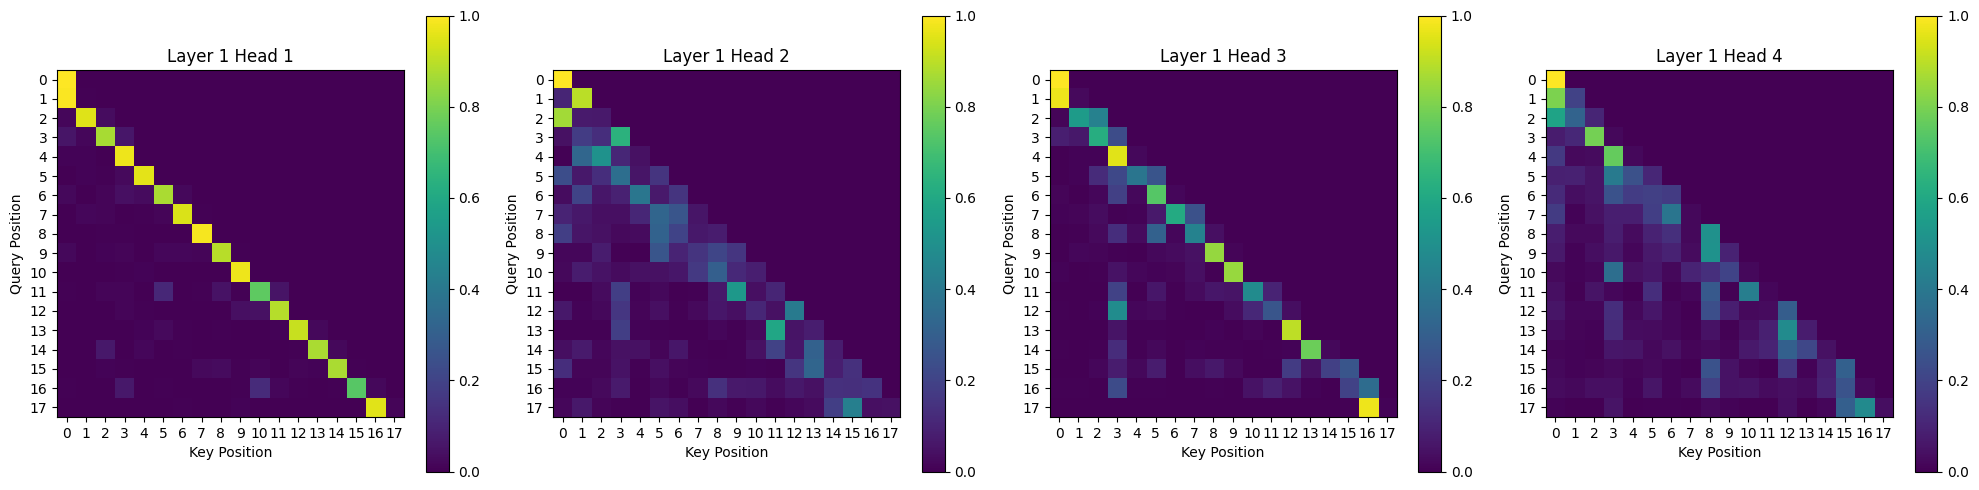

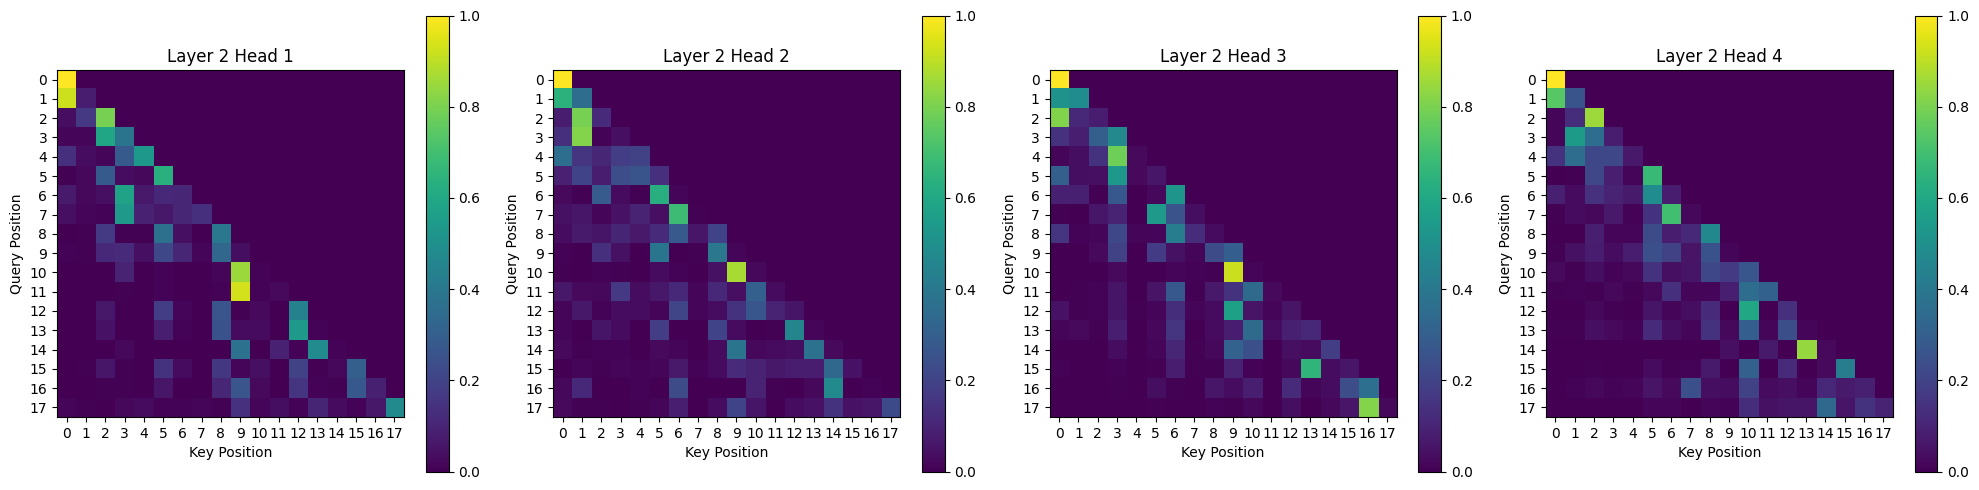

In [36]:
prompt = "To be or not to be"
visualize_attention(model, prompt)

# Conclusiones

### Para el Layer 1 o Capa 1 de la red:
Head 1 - atención local estricta (diagonal):
Es el más llamativo: la atención está casi exclusivamente sobre la diagonal principal, es decir, cada token atiende principalmente a sí mismo. Esto sugiere que este head actúa como un "passthrough" o identidad, pasando la información del token actual sin integrar contexto previo. Parece responder a un comportamiento conocido en GPTs pequeños donde algunos heads colapsan a la diagonal.

Head 2 - atención difusa con contexto amplio:
La masa de atención está distribuida en una franja más ancha alrededor de la diagonal. Cada token atiende a varios tokens anteriores con pesos similares. Este head pareciera integrar contexto local reciente, que es el comportamiento más "útil" para predecir el siguiente token.

Head 3 - mixto: diagonal + algunos saltos:
Similar al Head 1 pero con algunos puntos brillantes fuera de la diagonal. Estaría indicando que el modelo aprendió algunas dependencias específicas entre posiciones no adyacentes, aunque sea de forma incipiente dado el poco entrenamiento.

Head 4 - atención dispersa con saltos largos:
Ligeramente el más irregular: hay puntos de alta atención en posiciones bastante alejadas de la diagonal (ej. posición 8 atendiendo a posición 1, posición 14 a posición 7). Este head intenta capturar dependencias de largo alcance, aunque de forma ruidosa.

### Para el Layer 2:
Diferencia más importante: Layer 2 vs Layer 1
Lo primero que salta a la vista es que la diagonal desapareció casi por completo. Ningún head de la Layer 2 muestra ese patrón de "cada token atiende a sí mismo" que dominaba el Head 1 de la Capa 1. Esto es esperado: la Layer 2 recibe representaciones ya procesadas por la Layer 1, por lo que no necesita "recordar" el token actual, ya está integrado en el embedding que le llega.

Este comportamiento respondería a que sería la primera capa la encargada de extraer features básicas y la segunda capa razona sobre esas features (qué partes del contexto ya procesado son relevantes para predecir lo siguiente). Con más capas y más entrenamiento esta jerarquía se debería volver más pronunciada.


# ¡Felicitaciones! 🎉

Después de completar las tareas has preentrenado satisfactoriamente para fi... ¡Ahora puedes presumir ante tus amigos sobre cómo funcionan los LLM y los GPT!